In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Rename columns for better readability
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

# Drop the unnecessary columns
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

# Display the first 5 rows of the cleaned DataFrame
display(df.head())

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.sample(5)

,target,text
3190,spam,UR awarded a City Break and could WIN a å£200 ...
132,ham,First answer my question.
4465,ham,Hey u still at the gym?
2966,ham,NEFT Transaction with reference number &lt;#&...
4791,ham,Gd luck 4 ur exams :-)


In [ ]:
df.shape

(5572, 2)

In [ ]:
#data cleaning
#eda
#text preprocessing
#model building
#evaluation
#improvement
#website
#deploy

**DATA CLEANING**

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [ ]:
df.sample(5)

,target,text
2765,ham,and picking them up from various points
1445,ham,I am in a marriage function
168,ham,Great escape. I fancy the bridge but needs her...
1545,ham,"Good afternoon, my love ! Any job prospects ? ..."
4344,ham,Enjoy urself tmr...


In [ ]:
encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
df['target']=encoder.fit_transform(df['target'])

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#missing values
df.isnull().sum()

,0
target,0
text,0


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(403)

In [ ]:
#remove duplicates
df=df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.shape

(5169, 2)

**EDA**

In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


<function matplotlib.pyplot.show(close=None, block=None)>

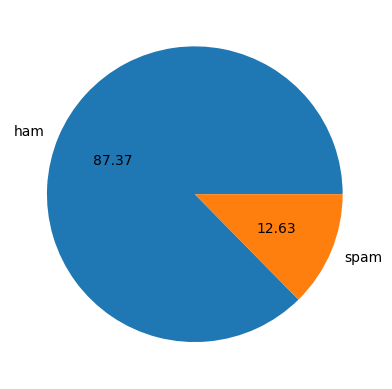

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show

In [ ]:
#data is imbalanced

In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df['num_characters']=df['text'].apply(len)

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#num of words
import nltk
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['text'].apply(lambda x:nltk.word_tokenize(x))

,text
0,"[Go, until, jurong, point, ,, crazy, .., Avail..."
1,"[Ok, lar, ..., Joking, wif, u, oni, ...]"
2,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,"[U, dun, say, so, early, hor, ..., U, c, alrea..."
4,"[Nah, I, do, n't, think, he, goes, to, usf, ,,..."
...,...
5567,"[This, is, the, 2nd, time, we, have, tried, 2,..."
5568,"[Will, Ì_, b, going, to, esplanade, fr, home, ?]"
5569,"[Pity, ,, *, was, in, mood, for, that, ., So, ..."
5570,"[The, guy, did, some, bitching, but, I, acted,..."


In [ ]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['text'].apply(lambda x:(nltk.sent_tokenize(x)))

,text
0,"[Go until jurong point, crazy.., Available onl..."
1,"[Ok lar..., Joking wif u oni...]"
2,[Free entry in 2 a wkly comp to win FA Cup fin...
3,[U dun say so early hor... U c already then sa...
4,"[Nah I don't think he goes to usf, he lives ar..."
...,...
5567,[This is the 2nd time we have tried 2 contact ...
5568,[Will Ì_ b going to esplanade fr home?]
5569,"[Pity, * was in mood for that., So...any other..."
5570,[The guy did some bitching but I acted like i'...


In [ ]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
#ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

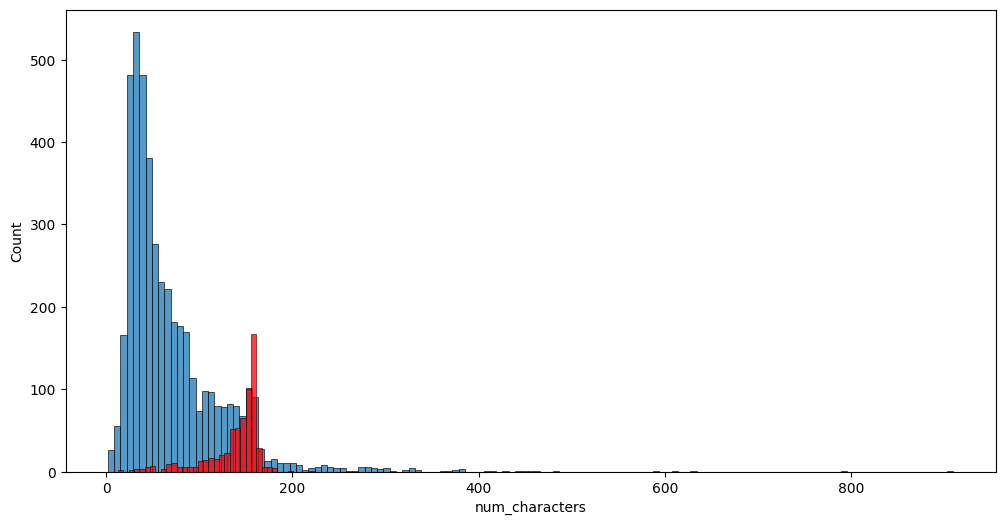

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

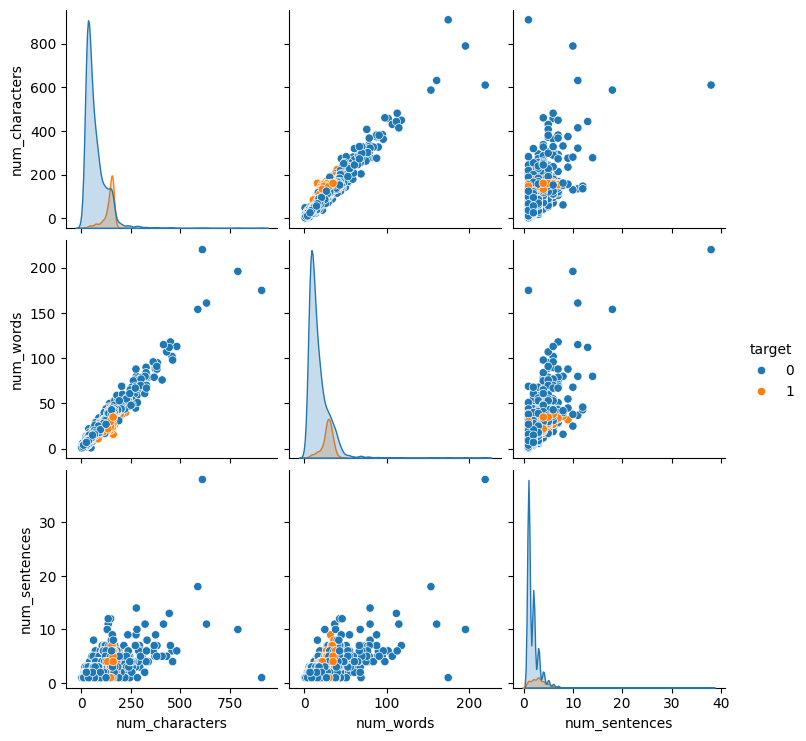

In [ ]:
sns.pairplot(df,hue='target')

In [ ]:
df[['target','num_characters','num_words','num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

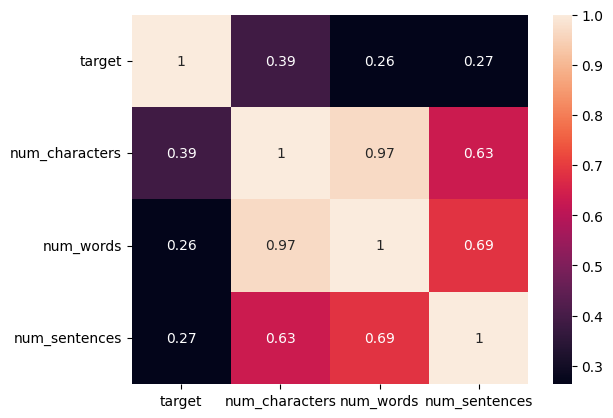

In [ ]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

**DATA PREPROCESSING**


*   Lower Case
*   Tokenization


*  Removing Special characters
*  Removing stop words and punctuation
Steaming









In [ ]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  return text

In [ ]:
transform_text("hi how are you %% eg")

['hi', 'how', 'are', 'you', '%', '%', 'eg']

In [ ]:
df['text'][2000]

"But i'll b going 2 sch on mon. My sis need 2 take smth."

In [ ]:
import string
from nltk.corpus import stopwords

def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:] # Create a copy to iterate over
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  return y

In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
transform_text('hi how are you')
transform_text('did you like my presentation on ml?')

['like', 'presentation', 'ml']

In [ ]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('dancing')

'danc'

In [ ]:
df['transformed_text']=df['text'].apply(transform_text)

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=50,min_font_size=10,background_color='white')

In [ ]:
wc.generate(df[df['target']==1]['transformed_text'].apply(lambda x: " ".join(x)).str.cat(sep=" "))

In [ ]:
for msg in df[df['target']==1]['transformed_text'].tolist():
  print(msg)

['free', 'entry', '2', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', '21st', 'may', 'text', 'fa', '87121', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 'c', 'apply', '08452810075over18']
['freemsg', 'hey', 'darling', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chgs', 'send', 'rcv']
['winner', 'valued', 'network', 'customer', 'selected', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hours']
['mobile', '11', 'months', 'u', 'r', 'entitled', 'update', 'latest', 'colour', 'mobiles', 'camera', 'free', 'call', 'mobile', 'update', 'co', 'free', '08002986030']
['six', 'chances', 'win', 'cash', '100', 'pounds', 'txt', 'csh11', 'send', 'cost', '6days', 'tsandcs', 'apply', 'reply', 'hl', '4', 'info']
['urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18']
['xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 

In [ ]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg:
    spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9939

In [ ]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,302
1,free,191
2,2,155
3,txt,130
4,u,119
5,ur,119
6,mobile,105
7,text,104
8,stop,104
9,4,97


<Axes: xlabel='0', ylabel='1'>

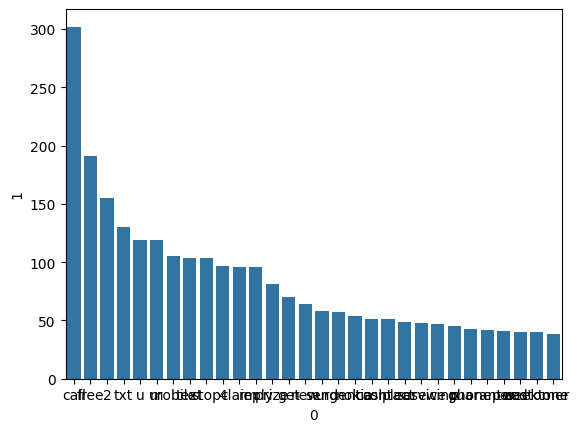

In [ ]:
from collections import Counter
import seaborn as sns
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])

In [ ]:
len(ham_corpus)

NameError: name 'ham_corpus' is not defined

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [ ]:
x = cv.fit_transform(df['transformed_text'].apply(lambda x: " ".join(x))).toarray()

In [ ]:
x.shape

(5169, 8002)

In [ ]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9013539651837524
[[811  85]
 [ 17 121]]
0.587378640776699


In [ ]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9680851063829787
[[892   4]
 [ 29 109]]
0.9646017699115044


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'Bgc':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9294003868471954, 0.76)

In [ ]:
accuracy_scores

[0.9294003868471954,
 0.902321083172147,
 0.9671179883945842,
 0.9216634429400387,
 0.9709864603481625,
 0.9671179883945842,
 0.9197292069632496,
 0.960348162475822,
 0.9738878143133463,
 0.9429400386847195,
 0.9729206963249516]

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9294003868471954
Precision -  0.76
For  KN
Accuracy -  0.902321083172147
Precision -  1.0
For  NB
Accuracy -  0.9671179883945842
Precision -  0.8421052631578947
For  DT
Accuracy -  0.9216634429400387
Precision -  0.9253731343283582
For  LR
Accuracy -  0.9709864603481625
Precision -  0.9821428571428571
For  RF
Accuracy -  0.9671179883945842
Precision -  0.9905660377358491
For  AdaBoost
Accuracy -  0.9197292069632496
Precision -  0.9661016949152542
For  Bgc
Accuracy -  0.960348162475822
Precision -  0.9369369369369369
For  ETC
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  GBDT
Accuracy -  0.9429400386847195
Precision -  0.9540229885057471
For  xgb
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
display(performance_df)

,Algorithm,Accuracy,Precision
1,KN,0.902321,1.000000
5,RF,0.967118,0.990566
8,ETC,0.973888,0.982609
4,LR,0.970986,0.982143
10,xgb,0.972921,0.974138
6,AdaBoost,0.919729,0.966102
9,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
3,DT,0.921663,0.925373
2,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys()})
performance_df = performance_df.merge(temp_df,on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
display(performance_df)

,Algorithm,Accuracy,Precision
0,KN,0.902321,1.000000
1,RF,0.967118,0.990566
2,ETC,0.973888,0.982609
3,LR,0.970986,0.982143
4,xgb,0.972921,0.974138
5,AdaBoost,0.919729,0.966102
6,GBDT,0.942940,0.954023
7,Bgc,0.960348,0.936937
8,DT,0.921663,0.925373
9,NB,0.967118,0.842105


In [ ]:
# Placeholder values for demonstration. Replace with actual values if available.
accuracy_max_ft_3000 = 0.95
precision_max_ft_3000 = 0.98

print(f"accuracy_max_ft_3000: {accuracy_max_ft_3000}")
print(f"precision_max_ft_3000: {precision_max_ft_3000}")

accuracy_max_ft_3000: 0.95
precision_max_ft_3000: 0.98


**MODEL BUILDING
**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [ ]:
X=tfidf.fit_transform(df['transformed_text'].apply(lambda x: " ".join(x))).toarray()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [ ]:
y=df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8878143133462283
[[795 101]
 [ 15 123]]
0.5491071428571429


In [ ]:

mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9806576402321083
[[891   5]
 [ 15 123]]
0.9609375


In [ ]:

bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9816247582205029
[[895   1]
 [ 18 120]]
0.9917355371900827


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:

clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:

train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9748549323017408, 0.9516129032258065)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9748549323017408
Precision -  0.9516129032258065
For  KN
Accuracy -  0.9032882011605415
Precision -  1.0
For  NB
Accuracy -  0.9806576402321083
Precision -  0.9609375
For  DT
Accuracy -  0.9400386847195358
Precision -  0.8725490196078431
For  LR
Accuracy -  0.9671179883945842
Precision -  0.9727272727272728
For  RF
Accuracy -  0.9777562862669246
Precision -  1.0
For  AdaBoost
Accuracy -  0.9294003868471954
Precision -  0.891566265060241
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8740157480314961
For  ETC
Accuracy -  0.9787234042553191
Precision -  0.9833333333333333
For  GBDT
Accuracy -  0.9458413926499033
Precision -  0.9019607843137255
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9411764705882353


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.903288,1.000000
5,RF,0.977756,1.000000
8,ETC,0.978723,0.983333
4,LR,0.967118,0.972727
2,NB,0.980658,0.960938
0,SVC,0.974855,0.951613
10,xgb,0.968085,0.941176
9,GBDT,0.945841,0.901961
6,AdaBoost,0.929400,0.891566
7,BgC,0.958414,0.874016


In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [ ]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.903288
1,RF,Accuracy,0.977756
2,ETC,Accuracy,0.978723
3,LR,Accuracy,0.967118
4,NB,Accuracy,0.980658
5,SVC,Accuracy,0.974855
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.945841
8,AdaBoost,Accuracy,0.929400
9,BgC,Accuracy,0.958414


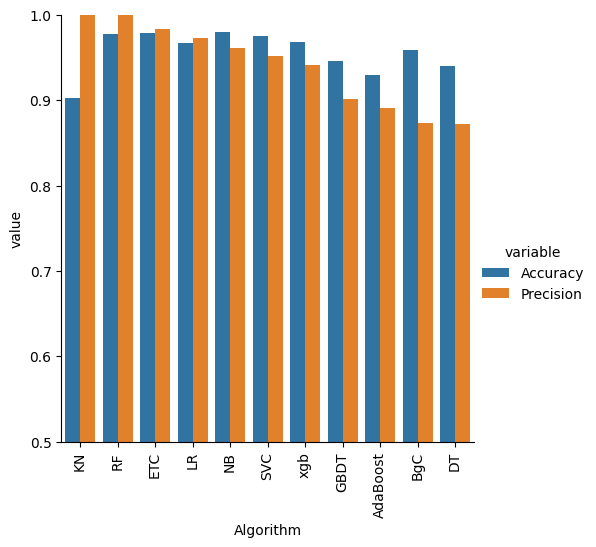

In [ ]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [ ]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [ ]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [ ]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.903288,1.000000,0.903288,1.000000,0.903288,1.000000,0.903288,1.000000
1,RF,0.977756,1.000000,0.977756,1.000000,0.977756,1.000000,0.977756,1.000000
2,ETC,0.978723,0.983333,0.978723,0.983333,0.978723,0.983333,0.978723,0.983333
3,LR,0.967118,0.972727,0.967118,0.972727,0.967118,0.972727,0.967118,0.972727
4,NB,0.980658,0.960938,0.980658,0.960938,0.980658,0.960938,0.980658,0.960938
5,SVC,0.974855,0.951613,0.974855,0.951613,0.974855,0.951613,0.974855,0.951613
6,xgb,0.968085,0.941176,0.968085,0.941176,0.968085,0.941176,0.968085,0.941176
7,GBDT,0.945841,0.901961,0.945841,0.901961,0.945841,0.901961,0.945841,0.901961
8,AdaBoost,0.929400,0.891566,0.929400,0.891566,0.929400,0.891566,0.929400,0.891566
9,BgC,0.958414,0.874016,0.958414,0.874016,0.958414,0.874016,0.958414,0.874016


In [ ]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

VOTING CLASSIFIER

In [ ]:
svc=SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb=MultinomialNB()
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)

from sklearn.ensemble import VotingClassifier

In [ ]:
voting=VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [ ]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

# Define the individual classifiers
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

# Prepare data for training
X=tfidf.fit_transform(df['transformed_text'].apply(lambda x: " ".join(x))).toarray()
y=df['target'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

# Define the Voting Classifier
voting=VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

voting.fit(X_train,y_train)
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.983739837398374


In [ ]:

# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:

clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9802690582959641
Precision 0.9788732394366197


In [ ]:

import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))